# Module 9: Full Anomaly Detection pipeline
## Data: ETH-USD (Stocks)

Structure: 
1. Data Ingestion & Safeguards
2. Adaptive Feature Engineering
3. Structural STL Decomposition
4. Global Outlier Flagging
5. Predictive Forecast Tracking
6. ML Matrix Aggregation
7. Density-Based Isolation Forest
8. Geometric One-Class SVM
9. Hybrid Consensus Synthesis
10. Multi-Panel Performance Dashboard

## 1. Install & Load Data (Yahoo Finance)

In [122]:
!pip install yfinance statsmodels scikit-learn matplotlib pandas numpy -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
import numpy as np
import pandas as pd
import yfinance as yf
from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

In [101]:
# Load Ethereum data
df = yf.download("ETH-USD", start="2022-01-01", end="2025-01-01")

# Flatten yfinance MultiIndex columns immediately
df.columns = df.columns.get_level_values(0)
df = df.reset_index()
df = df.sort_values("Date")

# Handle missing values (IMPORTANT)
df = df.dropna()

# Forward fill safety (optional but good for real-world data)
df = df.fillna(method="ffill")

[*********************100%***********************]  1 of 1 completed
C:\Users\oadsa\AppData\Local\Temp\ipykernel_18224\1268570297.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


## 2. Feature Engineering (Financial Signals)
Log returns make data more stable ✔

Log return transforms price into:

percentage-like change in continuous form

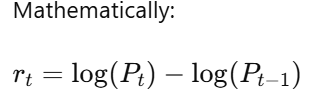

This converts:

multiplicative growth → additive changes

In [102]:
# Log returns (Log returns convert this into a normalized movement measure.)

df["return"] = np.log(df["Close"]).diff()

# Rolling statistics (volatility behavior)
df["rolling_mean"] = df["return"].rolling(10).mean()
df["rolling_std"] = df["return"].rolling(10).std()

# Momentum (trend strength)
df["momentum"] = df["Close"].pct_change(10)

# Clean NaNs from feature engineering
df = df.dropna()

## 3. STL Decomposition (Structure Removal)

In [103]:
# Decompose price into trend/seasonality/residual
stl = STL(df["Close"], period=30)
result = stl.fit()

df["trend"] = result.trend
df["seasonal"] = result.seasonal
df["residual"] = result.resid

## 4. Outlier Detection (3-Sigma Rule)

In [104]:
# Z-score of residuals
df["residual_mean"] = df["residual"].mean()
df["residual_std"] = df["residual"].std()
df["z_score"] = (df["residual"] - df["residual_mean"]) / df["residual_std"]

# 3-sigma anomaly detection
df["anomaly_3sigma"] = np.where(np.abs(df["z_score"]) > 3, 1, 0)

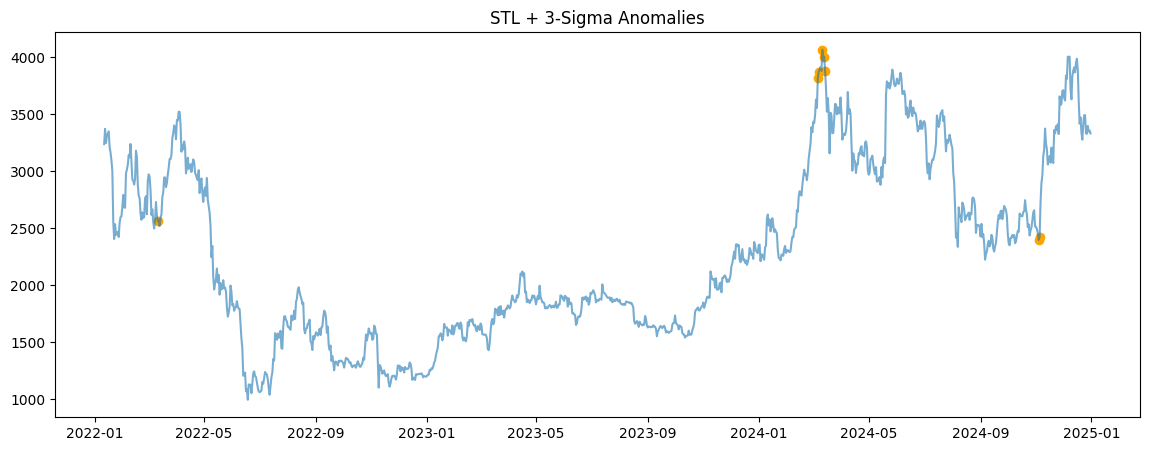

In [105]:
# VISUALIZATION 1: 3-SIGMA ONLY
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"], alpha=0.6)

a = df[df["anomaly_3sigma"] == 1]
plt.scatter(a["Date"], a["Close"], color="orange")

plt.title("STL + 3-Sigma Anomalies")
plt.show()

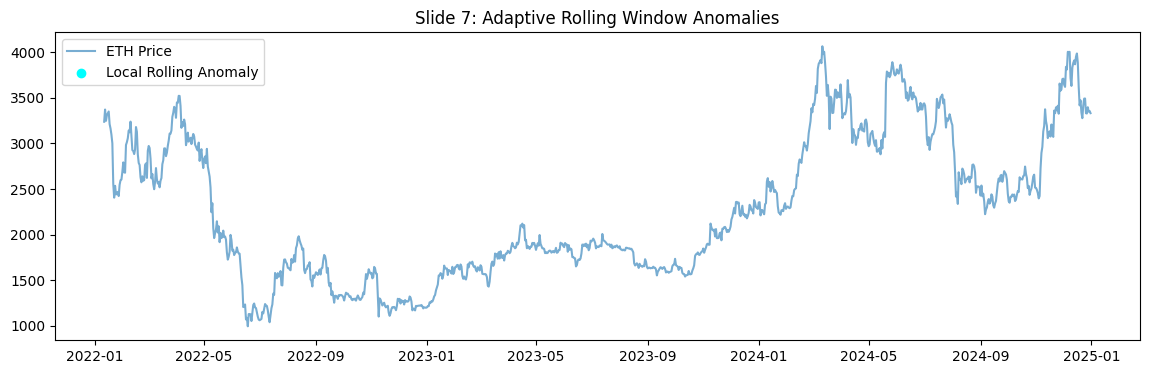

In [106]:
# daptive Rolling Window Anomaly Detection

# Compute local, moving Z-score using the engineered rolling features
df["rolling_z_score"] = (df["return"] - df["rolling_mean"]) / df["rolling_std"]

# Flag anomalies when current movement breaks local 10-day variance boundaries
df["anomaly_rolling"] = np.where(np.abs(df["rolling_z_score"]) > 3, 1, 0)

# Visualization
plt.figure(figsize=(14,4))
plt.plot(df["Date"], df["Close"], alpha=0.6, label="ETH Price")
rolling_anoms = df[df["anomaly_rolling"] == 1]
plt.scatter(rolling_anoms["Date"], rolling_anoms["Close"], color="cyan", label="Local Rolling Anomaly")
plt.title("Slide 7: Adaptive Rolling Window Anomalies")
plt.legend()
plt.show()

#### 1. STL Decomposition Plot

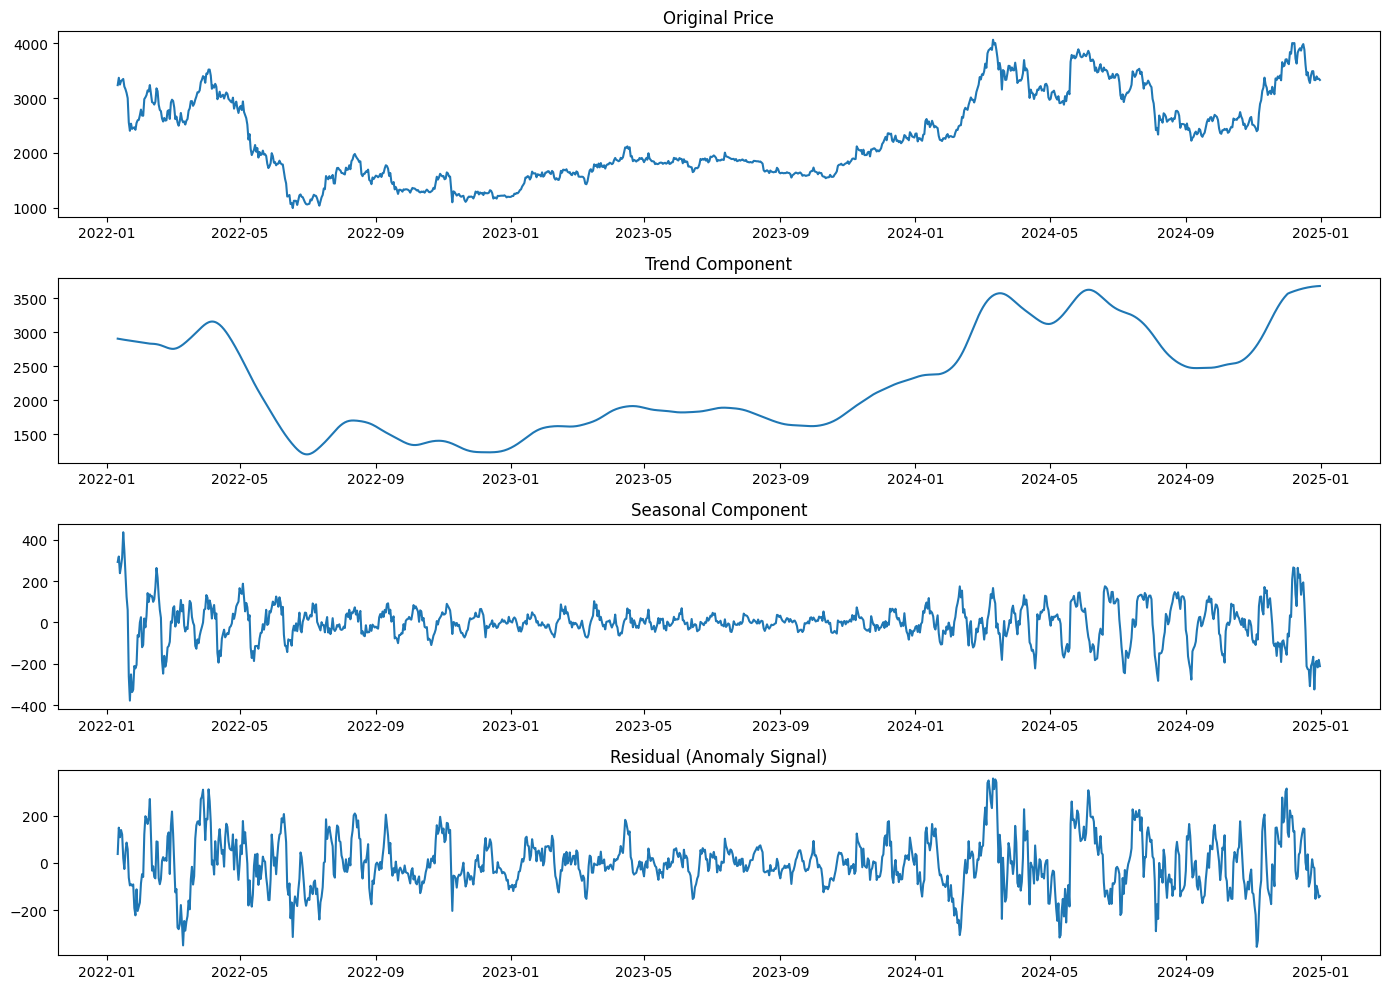

In [107]:
# VISUALIZATION: STL DECOMPOSITION
plt.figure(figsize=(14,10))

plt.subplot(4,1,1)
plt.plot(df["Date"], df["Close"])
plt.title("Original Price")

plt.subplot(4,1,2)
plt.plot(df["Date"], df["trend"])
plt.title("Trend Component")

plt.subplot(4,1,3)
plt.plot(df["Date"], df["seasonal"])
plt.title("Seasonal Component")

plt.subplot(4,1,4)
plt.plot(df["Date"], df["residual"])
plt.title("Residual (Anomaly Signal)")

plt.tight_layout()
plt.show()

#### 2. STL Residual + 3σ Anomalies

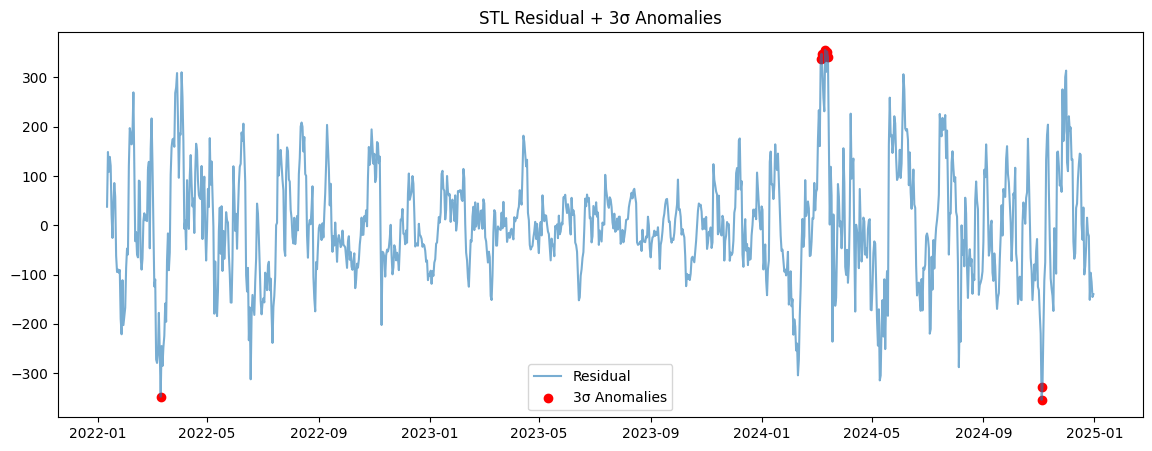

In [108]:
# =========================
# VISUALIZATION: STL RESIDUAL ANOMALIES
# =========================

plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["residual"], label="Residual", alpha=0.6)

a = df[df["anomaly_3sigma"] == 1]

plt.scatter(
    a["Date"],
    a["residual"],
    color="red",
    label="3σ Anomalies"
)

plt.title("STL Residual + 3σ Anomalies")
plt.legend()
plt.show()

## 5. Prophet Residual Anomaly Detection

In [109]:
#Prepare Prophet Dataset
prophet_df = df[["Date", "Close"]].copy()
prophet_df.columns = ["ds", "y"]

#Train Prophet
model = Prophet(yearly_seasonality=True,weekly_seasonality=True,daily_seasonality=False)

model.fit(prophet_df)

# Generate In-Sample Predictions
forecast = model.predict(prophet_df[["ds"]])

df["prophet_forecast"] = forecast["yhat"].values

# Calculate Residuals (Residual:Actual − Expected)
df["prophet_residual"] = (df["Close"] - df["prophet_forecast"])

# Detect Anomalies
threshold = (3 *df["prophet_residual"].std())

df["anomaly_prophet"] = np.where(np.abs(df["prophet_residual"]) > threshold,1, 0)

13:30:43 - cmdstanpy - INFO - Chain [1] start processing
13:30:43 - cmdstanpy - INFO - Chain [1] done processing


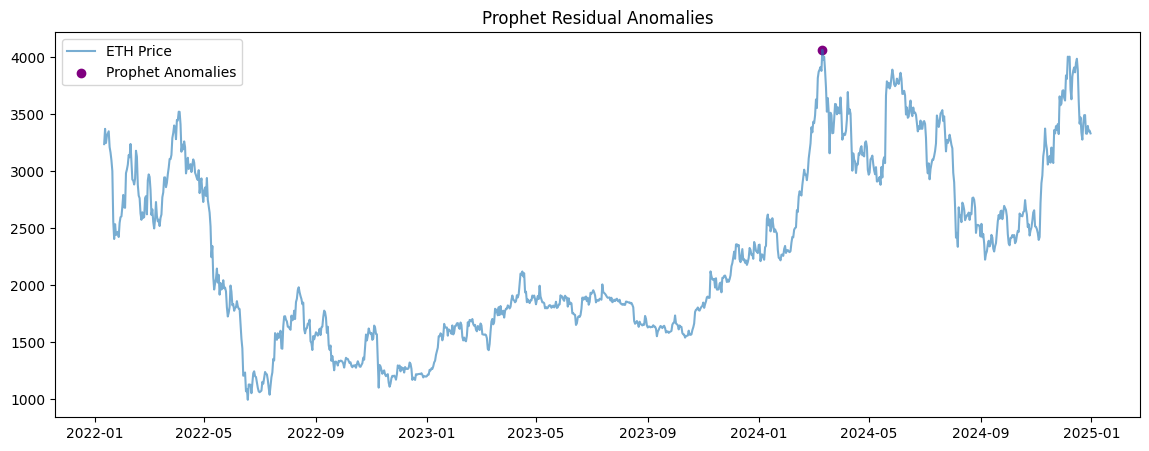

In [110]:
# Visualization
plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Close"],
    alpha=0.6,
    label="ETH Price"
)

a = df[df["anomaly_prophet"] == 1]

plt.scatter(
    a["Date"],
    a["Close"],
    color="purple",
    label="Prophet Anomalies"
)

plt.title("Prophet Residual Anomalies")
plt.legend()
plt.show()

## 6. Feature Set for ML Models

In [111]:
features = [
    "return",
    "rolling_mean",
    "rolling_std",
    "momentum"
]

X = df[features]

## 7. Isolation Forest (Unsupervised ML)

In [112]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42
)

df["iso_pred"] = iso.fit_predict(X)

# Convert to binary anomaly flag
df["anomaly_iso"] = df["iso_pred"].map({1: 0, -1: 1})

In [113]:
print("Anomalies Found:",
      df["anomaly_iso"].sum())

Anomalies Found: 22


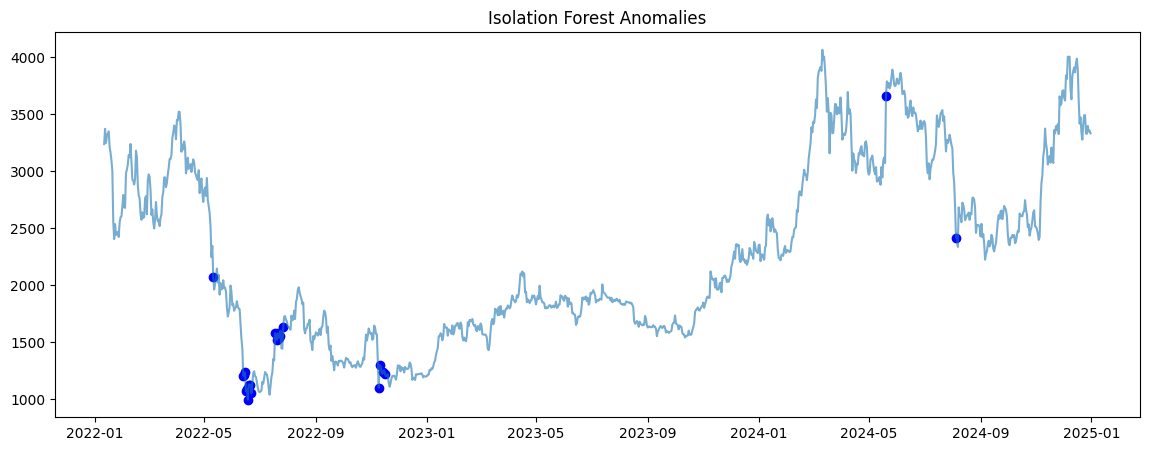

In [114]:
# VISUALIZATION 2: ISOLATION FOREST
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"], alpha=0.6)

a = df[df["anomaly_iso"] == 1]
plt.scatter(a["Date"], a["Close"], color="blue")

plt.title("Isolation Forest Anomalies")
plt.show()

## 8. One-Class SVM (Boundary Model)

In [115]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(nu=0.02, kernel="rbf", gamma="scale")
df["svm_pred"] = ocsvm.fit_predict(X)

df["anomaly_svm"] = df["svm_pred"].map({1: 0, -1: 1})

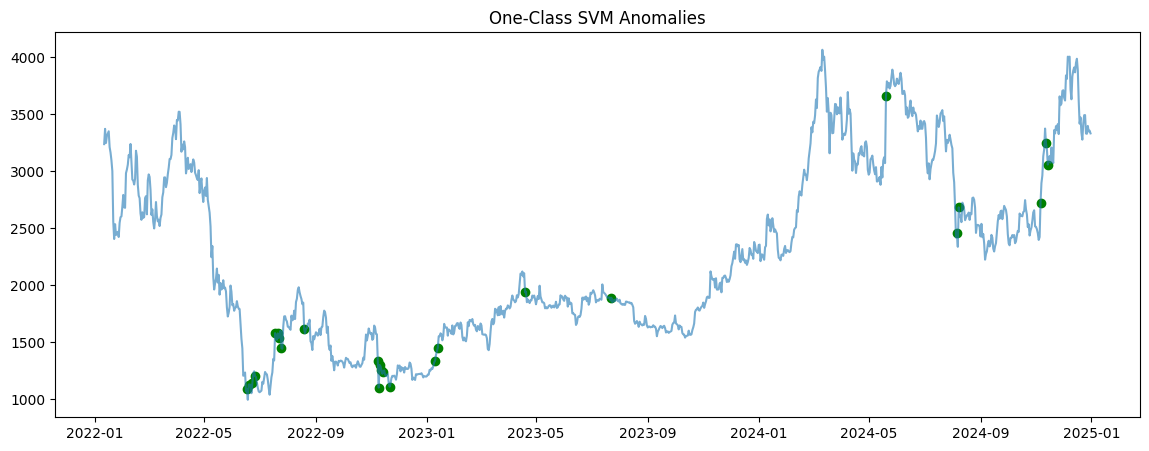

In [116]:
# VISUALIZATION 3: SVM
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"], alpha=0.6)

a = df[df["anomaly_svm"] == 1]
plt.scatter(a["Date"], a["Close"], color="green")

plt.title("One-Class SVM Anomalies")
plt.show()

## Model Components
- 3σ (Statistical Shock Detector)
Detects extreme price movements based on standard deviation of STL residuals. Assumes rare events indicate market risk.
- Isolation Forest (Density-Based Anomaly Detector)
Identifies unusual patterns in feature space. Does not assume any statistical distribution.
- One-Class SVM (Boundary-Based Anomaly Detector)
Learns the boundary of normal market behavior and flags points outside it as anomalies.

## 9. Final Hybrid Anomaly Signal 
We combine:

- Statistical (3σ)
- prophet
- ML (Isolation Forest)
- ML (SVM)

In [117]:
# Combined Agreement score across all 4 unique approaches
df["agreement_score"] = (
    df["anomaly_3sigma"] +
    df["anomaly_rolling"] +
    df["anomaly_prophet"] + 
    df["anomaly_iso"] +
    df["anomaly_svm"]
)

# Core Rule: High-confidence anomaly if 2 or more models find consensus
df["final_anomaly"] = np.where(df["agreement_score"] >= 2, 1, 0)

Agreement visualization

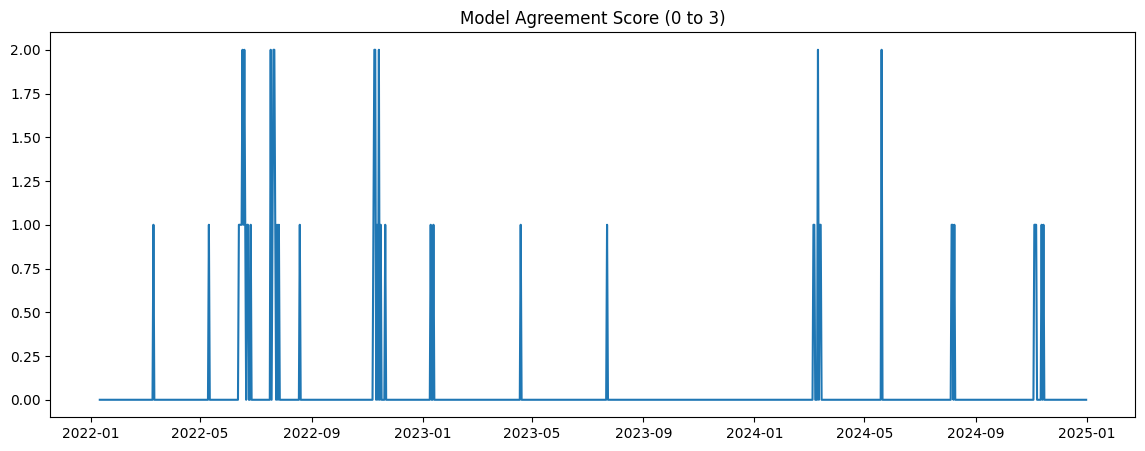

In [118]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["agreement_score"])

plt.title("Model Agreement Score (0 to 3)")
plt.show()

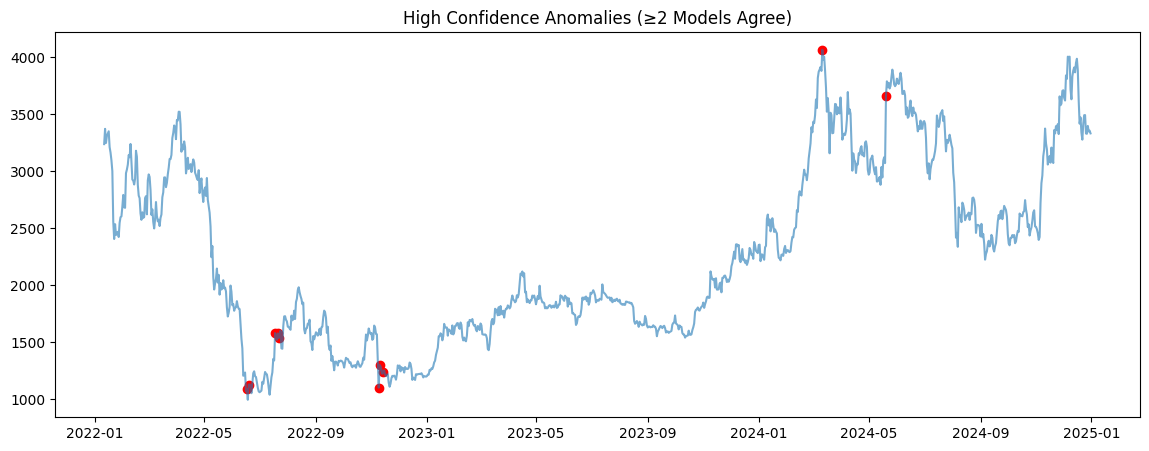

In [119]:
# VISUALIZATION 5: HIGH CONFIDENCE SIGNALS
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"], alpha=0.6)

high_conf = df[df["agreement_score"] >= 2]

plt.scatter(
    high_conf["Date"],
    high_conf["Close"],
    color="red"
)

plt.title("High Confidence Anomalies (≥2 Models Agree)")
plt.show()

| Score | Meaning                    | Confidence         |
| ----- | -------------------------- | ------------------ |
| 0     | Normal market behavior     | Low risk           |
| 1     | Weak signal (noise likely) | Low confidence     |
| 2     | Partial agreement          | Medium confidence  |
| 3     | Full consensus shock       | High confidence 🔴 |


## 10. Visualization - Final Hybrid Anomaly Signal 

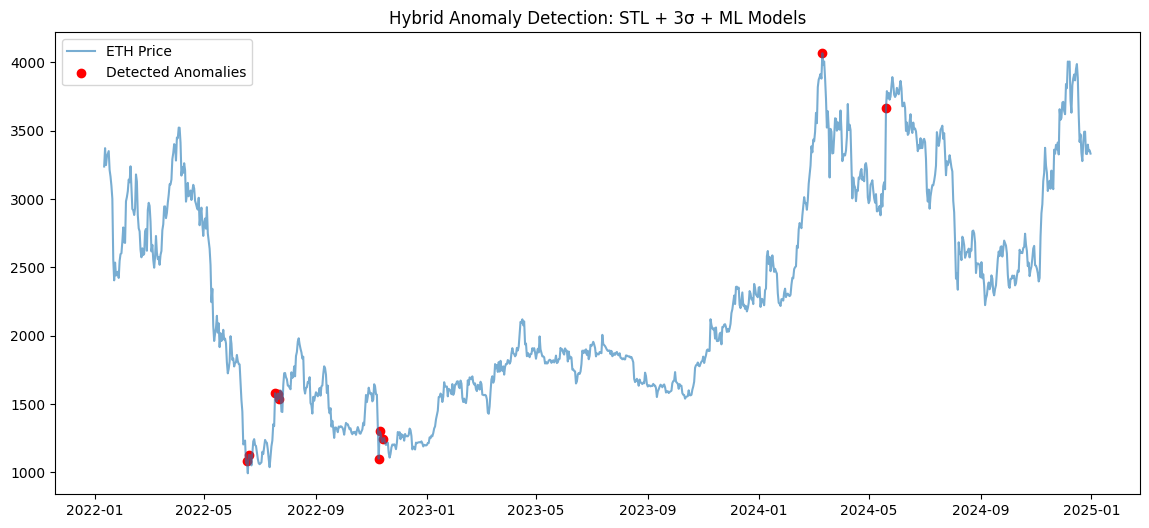

In [120]:

plt.figure(figsize=(14,6))

# Price line
plt.plot(df["Date"], df["Close"], label="ETH Price", alpha=0.6)

# Anomalies
anomalies = df[df["final_anomaly"] == 1]

plt.scatter(
    anomalies["Date"],
    anomalies["Close"],
    color="red",
    label="Detected Anomalies"
)

plt.title("Hybrid Anomaly Detection: STL + 3σ + ML Models")
plt.legend()
plt.show()